<a href="https://colab.research.google.com/github/saanvikompelli-cmd/2520030083_ML/blob/main/Project/Frontend_Fake_News_Detection(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
# ============================================================
# CELL 1 - IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import os
import re
import string
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [34]:
# ============================================================
# CELL 2 - LOAD FAKE NEWS DATASET
# ============================================================

from pandas import read_csv

dataset_path = "/content/Fake_News_Detection_Dataset_2000.csv"

df = read_csv(dataset_path)

print("Dataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

Dataset loaded successfully!

Dataset Shape:
(2000, 18)

Dataset Columns:
['News_ID', 'Title', 'Text', 'Source', 'Subject', 'Author', 'PublishedDate', 'TextLength', 'WordCount', 'SentimentScore', 'CapitalWordRatio', 'PunctuationCount', 'URLCount', 'ExclamationCount', 'QuestionCount', 'ReadabilityScore', 'SourceCredibilityScore', 'class']

First 5 Records:


,News_ID,Title,Text,Source,Subject,Author,PublishedDate,TextLength,WordCount,SentimentScore,CapitalWordRatio,PunctuationCount,URLCount,ExclamationCount,QuestionCount,ReadabilityScore,SourceCredibilityScore,class
0,41376,Officials Announce New Policy Update,Researchers reported findings from a study and...,Times of India,Technology,Editorial Team,2019-06-20,241,34,0.221,0.0000,2,0,0,0,90.00,98.81,1
1,8711,URGENT REPORT: Hidden Details Exposed,SHOCKING NEWS: A controversial claim has appea...,Viral News Network,Health,Unknown,2022-08-06,220,34,0.506,0.0588,3,0,1,0,42.06,25.51,0
2,43651,Researchers Publish New Study Findings,The company released its quarterly results and...,NDTV,Technology,Editorial Team,2025-01-18,235,34,0.058,0.0000,2,0,0,0,61.26,93.09,1
3,12638,Secret Truth Revealed Online,SHOCKING NEWS: A controversial claim has appea...,Unknown Source,Politics,Viral Desk,2024-03-25,220,34,0.150,0.0588,3,1,1,0,52.90,29.49,0
4,37308,Officials Announce New Policy Update,Researchers reported findings from a study and...,Associated Press,Technology,Editorial Team,2019-09-22,241,34,-0.088,0.0000,2,0,0,0,41.61,69.96,1


In [35]:
# ============================================================
# CELL 3 - BASIC DATASET INFORMATION
# ============================================================

print("========== DATASET INFORMATION ==========")

print("Total Records:", len(df))
print("Total Columns:", len(df.columns))

print("\nColumn Names:")
for column in df.columns:
    print("-", column)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

========== DATASET INFORMATION ==========
Total Records: 2000
Total Columns: 18

Column Names:
- News_ID
- Title
- Text
- Source
- Subject
- Author
- PublishedDate
- TextLength
- WordCount
- SentimentScore
- CapitalWordRatio
- PunctuationCount
- URLCount
- ExclamationCount
- QuestionCount
- ReadabilityScore
- SourceCredibilityScore
- class

Data Types:
News_ID                     int64
Title                      object
Text                       object
Source                     object
Subject                    object
Author                     object
PublishedDate              object
TextLength                  int64
WordCount                   int64
SentimentScore            float64
CapitalWordRatio          float64
PunctuationCount            int64
URLCount                    int64
ExclamationCount            int64
QuestionCount               int64
ReadabilityScore          float64
SourceCredibilityScore    float64
class                       int64
dtype: object

Dataset Informatio

In [36]:
# ============================================================
# CELL 4 - NUMERICAL VS CATEGORICAL FEATURES
# ============================================================

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = df.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['News_ID', 'TextLength', 'WordCount', 'SentimentScore', 'CapitalWordRatio', 'PunctuationCount', 'URLCount', 'ExclamationCount', 'QuestionCount', 'ReadabilityScore', 'SourceCredibilityScore', 'class']

Categorical Features:
['Title', 'Text', 'Source', 'Subject', 'Author', 'PublishedDate']


In [37]:
# ============================================================
# CELL 5 - MISSING VALUE ANALYSIS
# ============================================================

print("========== MISSING VALUE ANALYSIS ==========")

missing_values = df.isnull().sum()

display(missing_values.to_frame("Missing Values"))

print(
    "\nTotal Missing Values:",
    df.isnull().sum().sum()
)

========== MISSING VALUE ANALYSIS ==========


,Missing Values
News_ID,0
Title,0
Text,0
Source,0
Subject,0
Author,0
PublishedDate,0
TextLength,0
WordCount,0
SentimentScore,0



Total Missing Values: 0


In [38]:
# ============================================================
# CELL 6 - DUPLICATE RECORD ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Total Duplicate Records:", duplicate_count)

Total Duplicate Records: 0


========== LABEL DISTRIBUTION ==========

Class Counts:
label
1    1000
0    1000
Name: count, dtype: int64

Percentage Distribution:
label
1    50.0
0    50.0
Name: proportion, dtype: float64

Unique Labels:
[1 0]

Label Mapping:
0 = Fake News
1 = Real News


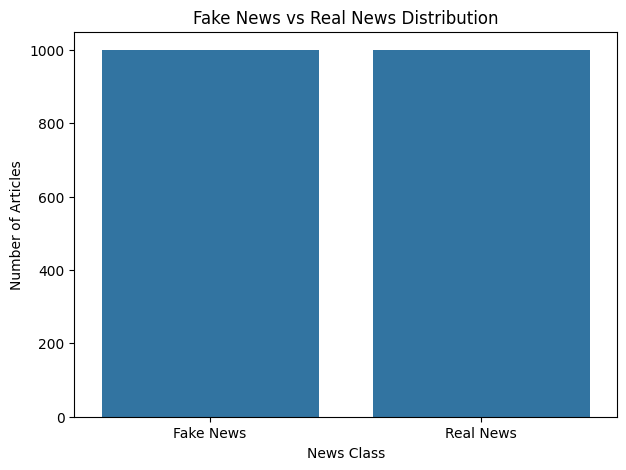

In [39]:
# ============================================================
# CELL 7 - LABEL DISTRIBUTION
# ============================================================

print("========== LABEL DISTRIBUTION ==========")

# Your dataset uses 'class' as the target column
# Create 'label' so the remaining project can use it
df["label"] = df["class"]

# Display class counts
print("\nClass Counts:")
print(df["label"].value_counts())

# Display percentage distribution
print("\nPercentage Distribution:")
print(
    (df["label"].value_counts(normalize=True) * 100).round(2)
)

# Display unique labels
print("\nUnique Labels:")
print(df["label"].unique())

# Display label meaning
print("\nLabel Mapping:")
print("0 = Fake News")
print("1 = Real News")

# Plot label distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Fake News vs Real News Distribution")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")

plt.xticks(
    [0, 1],
    ["Fake News", "Real News"]
)

plt.show()

In [40]:
# ============================================================
# CELL 8 - LABEL MAPPING
# ============================================================

LABEL_NAMES = {
    0: "Fake News",
    1: "Real News"
}

# Convert numeric labels into readable names
df["News_Type"] = df["label"].map(LABEL_NAMES)

print("========== LABEL MAPPING ==========")

print("\nLabel Mapping:")
print("0 = Fake News")
print("1 = Real News")

print("\nNews Type Distribution:")
print(df["News_Type"].value_counts())

# Check if any labels could not be mapped
print("\nUnique News Types:")
print(df["News_Type"].unique())

========== LABEL MAPPING ==========

Label Mapping:
0 = Fake News
1 = Real News

News Type Distribution:
News_Type
Real News    1000
Fake News    1000
Name: count, dtype: int64

Unique News Types:
['Real News' 'Fake News']


========== FAKE VS REAL NEWS DISTRIBUTION ==========


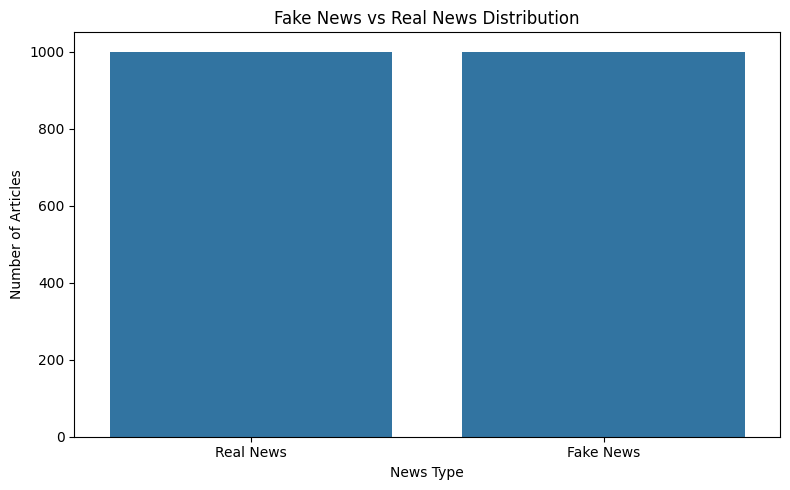

In [41]:
# ============================================================
# CELL 9 - FAKE VS REAL NEWS DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("========== FAKE VS REAL NEWS DISTRIBUTION ==========")

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="News_Type"
)

plt.title("Fake News vs Real News Distribution")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# CELL 10 - COMBINE TITLE AND ARTICLE TEXT
# ============================================================

# Handle missing values
df["Title"] = df["Title"].fillna("")
df["Text"] = df["Text"].fillna("")

# Combine title and article text
df["combined_text"] = (
    df["Title"].astype(str) + " " +
    df["Text"].astype(str)
)

print("Title and article text combined successfully!")

# Display first 5 records
display(
    df[
        ["Title", "Text", "combined_text", "label"]
    ].head()
)

Title and article text combined successfully!


,Title,Text,combined_text,label
0,Officials Announce New Policy Update,Researchers reported findings from a study and...,Officials Announce New Policy Update Researche...,1
1,URGENT REPORT: Hidden Details Exposed,SHOCKING NEWS: A controversial claim has appea...,URGENT REPORT: Hidden Details Exposed SHOCKING...,0
2,Researchers Publish New Study Findings,The company released its quarterly results and...,Researchers Publish New Study Findings The com...,1
3,Secret Truth Revealed Online,SHOCKING NEWS: A controversial claim has appea...,Secret Truth Revealed Online SHOCKING NEWS: A ...,0
4,Officials Announce New Policy Update,Researchers reported findings from a study and...,Officials Announce New Policy Update Researche...,1


In [43]:
# ============================================================
# CELL 11 - NLP TEXT PREPROCESSING
# ============================================================

import re
import string

def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        "",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# Apply NLP preprocessing
df["clean_text"] = df["combined_text"].apply(clean_text)

print("NLP preprocessing completed successfully!")

# Display original and cleaned text
display(
    df[
        ["combined_text", "clean_text", "label"]
    ].head()
)

NLP preprocessing completed successfully!


,combined_text,clean_text,label
0,Officials Announce New Policy Update Researche...,officials announce new policy update researche...,1
1,URGENT REPORT: Hidden Details Exposed SHOCKING...,urgent report hidden details exposed shocking ...,0
2,Researchers Publish New Study Findings The com...,researchers publish new study findings the com...,1
3,Secret Truth Revealed Online SHOCKING NEWS: A ...,secret truth revealed online shocking news a c...,0
4,Officials Announce New Policy Update Researche...,officials announce new policy update researche...,1


In [44]:
# ============================================================
# CELL 12 - CREATE TEXT FEATURES
# ============================================================

import string
import re

# ------------------------------------------------------------
# 1. Text Length
# ------------------------------------------------------------
df["TextLength"] = df["clean_text"].apply(len)

# ------------------------------------------------------------
# 2. Number of Words
# ------------------------------------------------------------
df["WordCount"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

# ------------------------------------------------------------
# 3. Number of Punctuation Marks
# ------------------------------------------------------------
df["PunctuationCount"] = df["combined_text"].apply(
    lambda x: sum(
        1 for char in str(x)
        if char in string.punctuation
    )
)

# ------------------------------------------------------------
# 4. Number of URLs
# ------------------------------------------------------------
df["URLCount"] = df["combined_text"].apply(
    lambda x: len(
        re.findall(
            r"http\S+|www\S+|https\S+",
            str(x)
        )
    )
)

# ------------------------------------------------------------
# 5. Number of Exclamation Marks
# ------------------------------------------------------------
df["ExclamationCount"] = df["combined_text"].apply(
    lambda x: str(x).count("!")
)

# ------------------------------------------------------------
# 6. Number of Question Marks
# ------------------------------------------------------------
df["QuestionCount"] = df["combined_text"].apply(
    lambda x: str(x).count("?")
)

print("Text features created successfully!")

# Display the created features
display(
    df[
        [
            "TextLength",
            "WordCount",
            "PunctuationCount",
            "URLCount",
            "ExclamationCount",
            "QuestionCount",
            "label"
        ]
    ].head()
)

Text features created successfully!


,TextLength,WordCount,PunctuationCount,URLCount,ExclamationCount,QuestionCount,label
0,275,39,2,0,0,0,1
1,253,39,4,0,1,0,0
2,271,39,2,0,0,0,1
3,245,38,3,0,1,0,0
4,275,39,2,0,0,0,1


========== TEXT LENGTH AND WORD COUNT ANALYSIS ==========

Text Length Statistics:


,TextLength
count,2000.000000
mean,261.269500
std,11.109031
min,239.000000
25%,252.000000
50%,261.000000
75%,271.000000
max,282.000000



Word Count Statistics:


,WordCount
count,2000.000000
mean,37.994000
std,0.991189
min,35.000000
25%,37.000000
50%,38.000000
75%,39.000000
max,40.000000


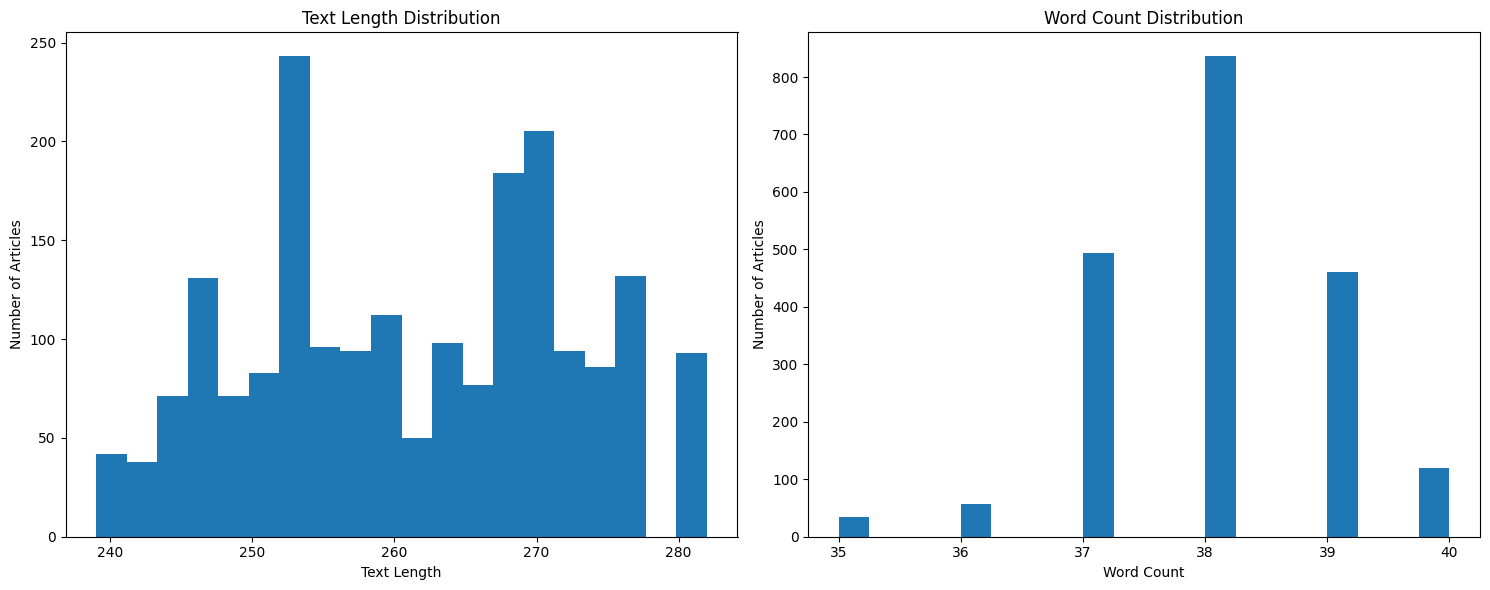

In [45]:
# ============================================================
# CELL 13 - TEXT LENGTH AND WORD COUNT ANALYSIS
# ============================================================

print("========== TEXT LENGTH AND WORD COUNT ANALYSIS ==========")

# Text Length statistics
print("\nText Length Statistics:")
display(df["TextLength"].describe())

# Word Count statistics
print("\nWord Count Statistics:")
display(df["WordCount"].describe())


# Create two graphs
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# ------------------------------------------------------------
# Text Length Distribution
# ------------------------------------------------------------
axes[0].hist(
    df["TextLength"],
    bins=20
)

axes[0].set_title(
    "Text Length Distribution"
)

axes[0].set_xlabel(
    "Text Length"
)

axes[0].set_ylabel(
    "Number of Articles"
)


# ------------------------------------------------------------
# Word Count Distribution
# ------------------------------------------------------------
axes[1].hist(
    df["WordCount"],
    bins=20
)

axes[1].set_title(
    "Word Count Distribution"
)

axes[1].set_xlabel(
    "Word Count"
)

axes[1].set_ylabel(
    "Number of Articles"
)

plt.tight_layout()
plt.show()

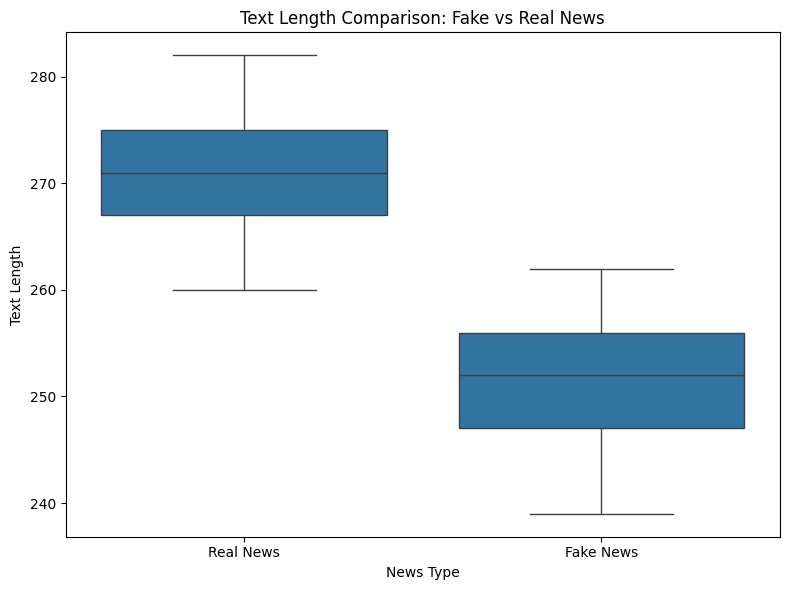

In [46]:
# ============================================================
# CELL 14 - TEXT LENGTH BY NEWS TYPE
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="News_Type",
    y="TextLength"
)

plt.title(
    "Text Length Comparison: Fake vs Real News"
)

plt.xlabel("News Type")
plt.ylabel("Text Length")

plt.tight_layout()
plt.show()

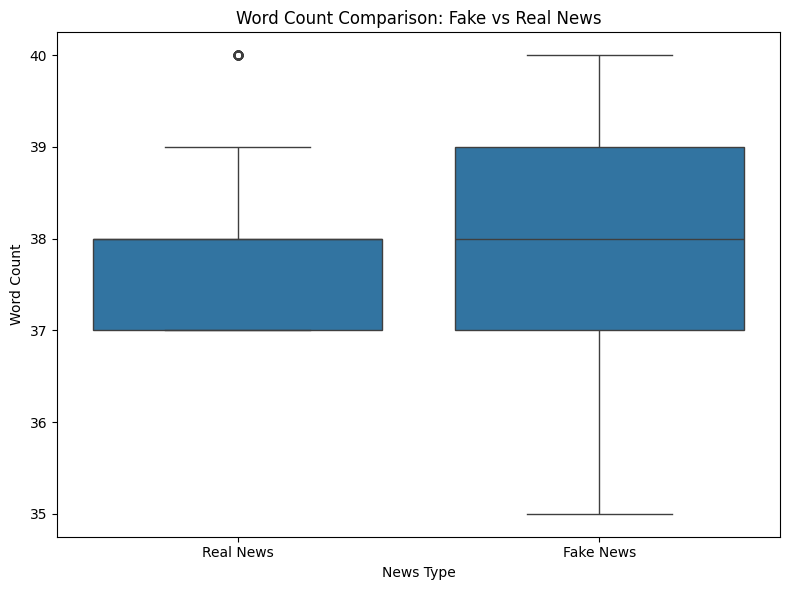

In [47]:
# ============================================================
# CELL 15 - WORD COUNT BY NEWS TYPE
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="News_Type",
    y="WordCount"
)

plt.title(
    "Word Count Comparison: Fake vs Real News"
)

plt.xlabel("News Type")
plt.ylabel("Word Count")

plt.tight_layout()
plt.show()

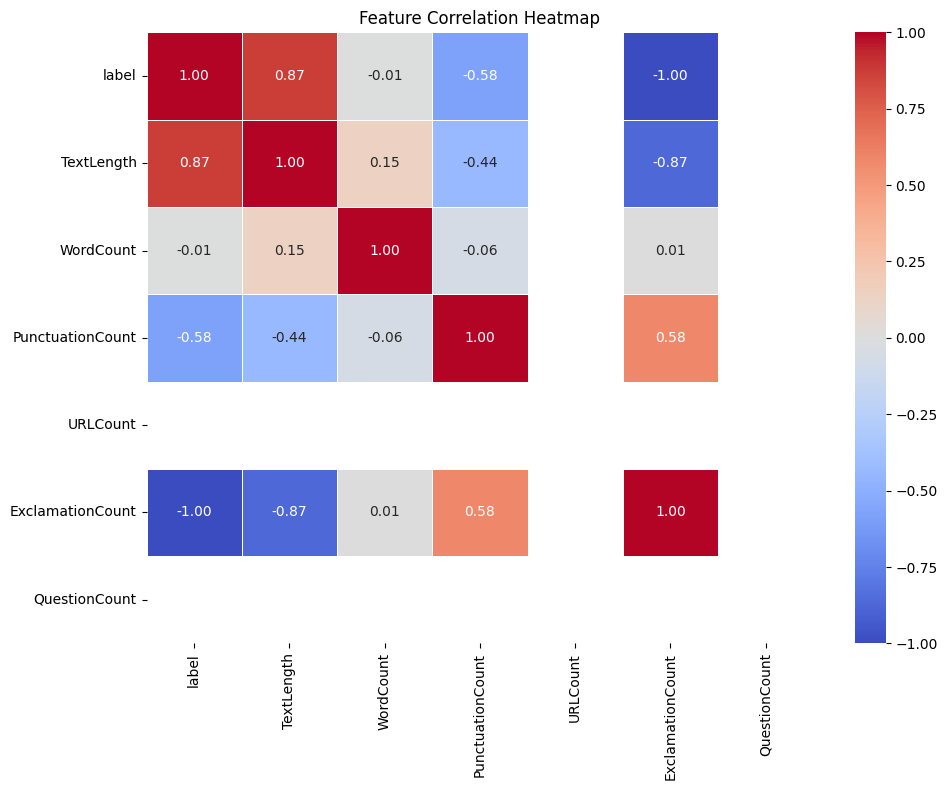

In [48]:
# ============================================================
# CELL 16 - FEATURE CORRELATION HEATMAP
# ============================================================

correlation_features = [
    "label",
    "TextLength",
    "WordCount",
    "PunctuationCount",
    "URLCount",
    "ExclamationCount",
    "QuestionCount"
]

# Calculate correlation
correlation_matrix = df[correlation_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

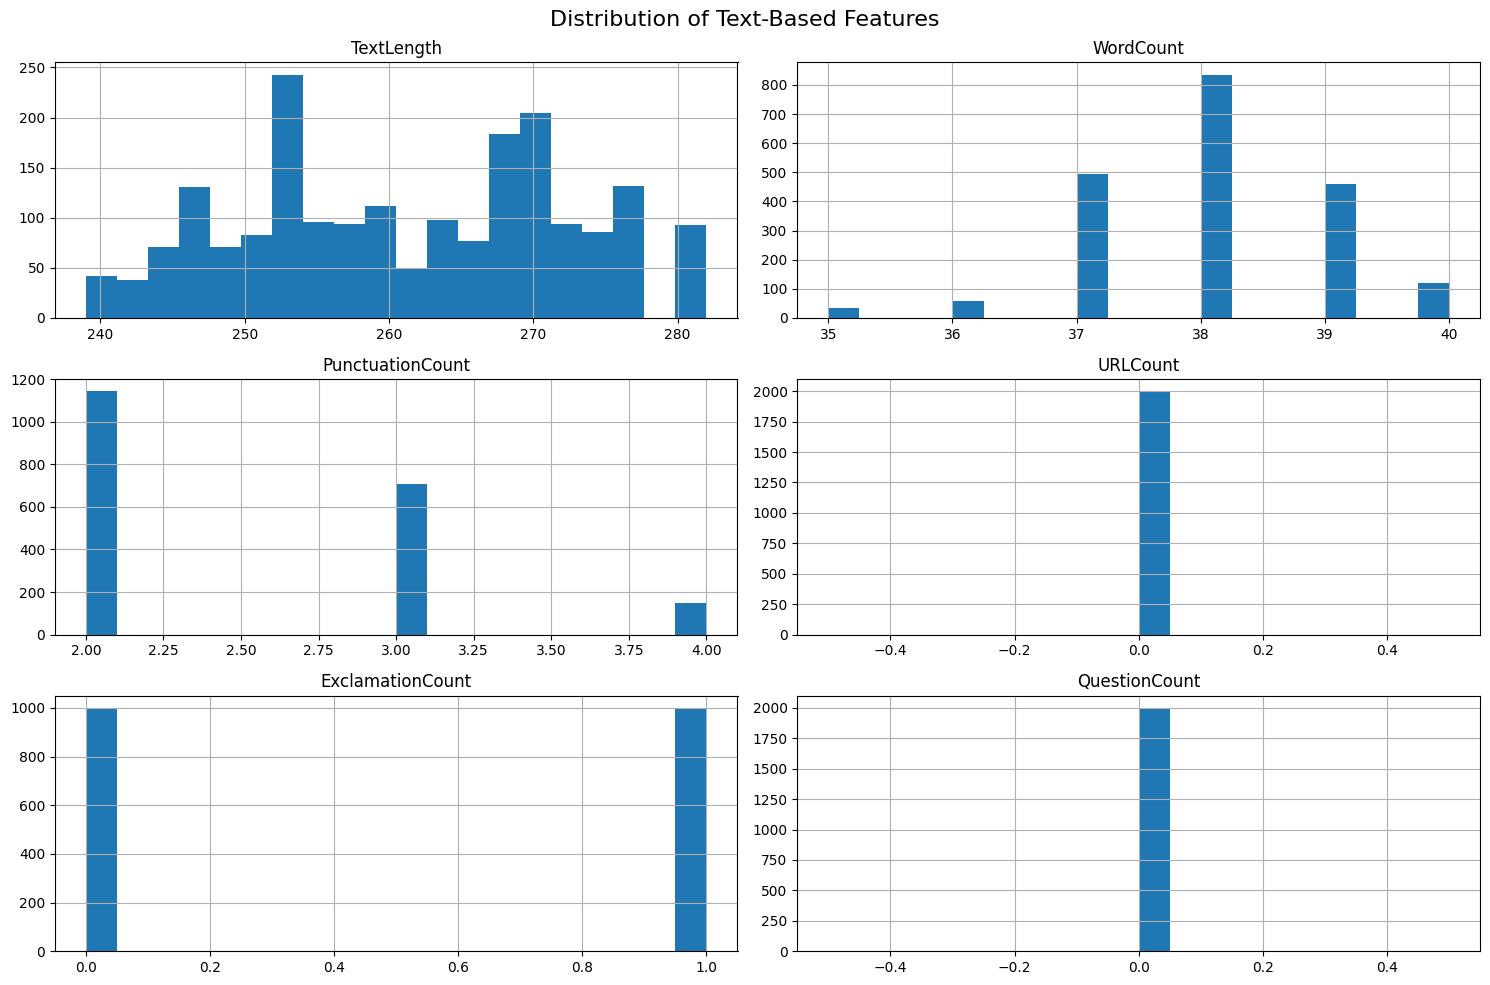

In [49]:
# ============================================================
# CELL 17 - FEATURE HISTOGRAMS
# ============================================================

hist_features = [
    "TextLength",
    "WordCount",
    "PunctuationCount",
    "URLCount",
    "ExclamationCount",
    "QuestionCount"
]

# Plot histograms
df[hist_features].hist(
    bins=20,
    figsize=(15, 10)
)

plt.suptitle(
    "Distribution of Text-Based Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

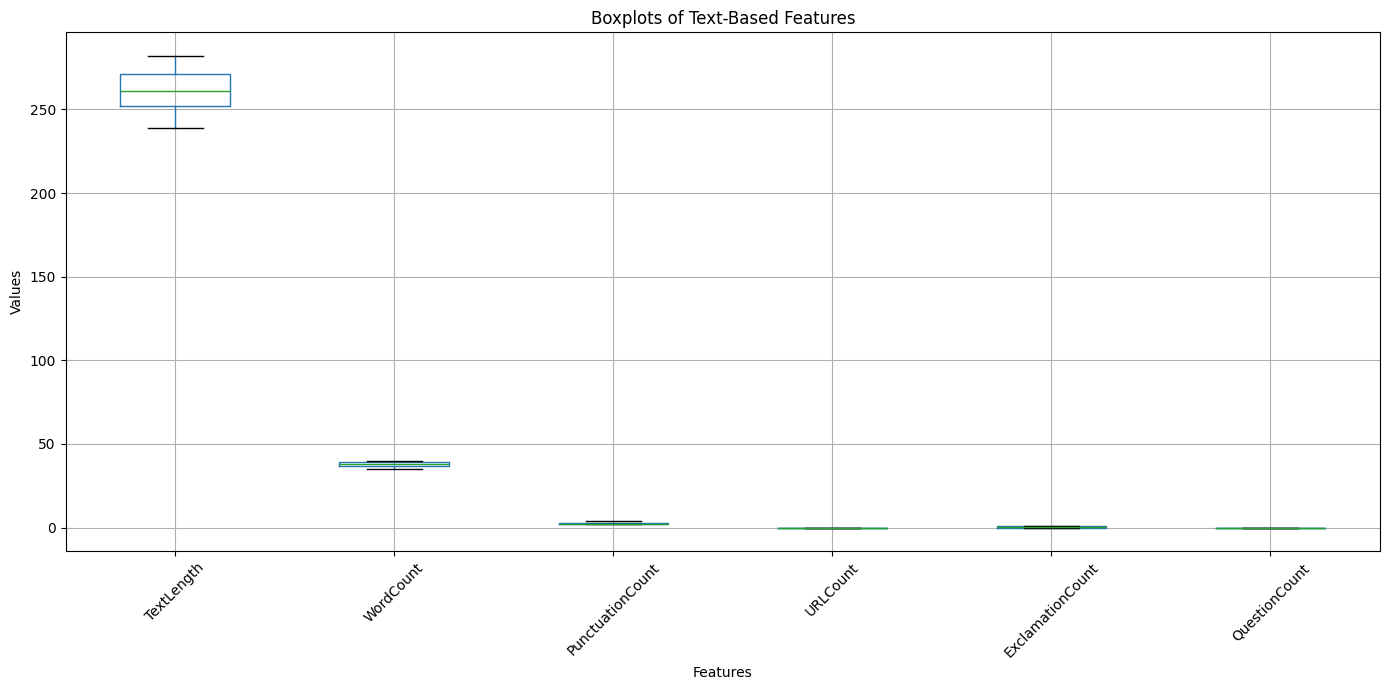

In [50]:
# ============================================================
# CELL 18 - FEATURE BOXPLOTS
# ============================================================

plt.figure(figsize=(14, 7))

df[hist_features].boxplot()

plt.title("Boxplots of Text-Based Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

========== SENSATIONALISM ANALYSIS ==========

Sensationalism Score Statistics:


,SensationalismScore
count,2000.00000
mean,1.00000
std,1.00025
min,0.00000
25%,0.00000
50%,1.00000
75%,2.00000
max,2.00000


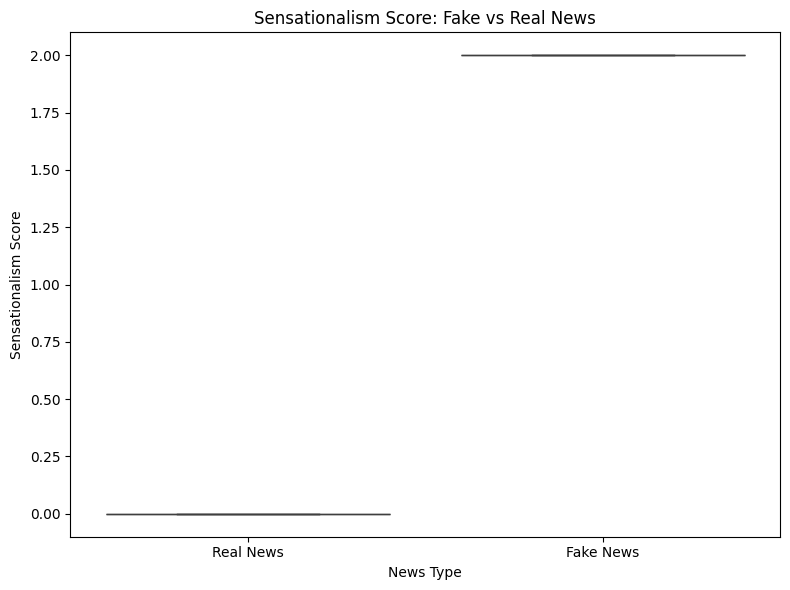

In [51]:
# ============================================================
# CELL 19 - SENSATIONALISM ANALYSIS
# ============================================================

# Create a simple sensationalism score
df["SensationalismScore"] = (
    df["ExclamationCount"] * 2
    + df["QuestionCount"]
)

print("========== SENSATIONALISM ANALYSIS ==========")

print("\nSensationalism Score Statistics:")
display(df["SensationalismScore"].describe())

# Compare Fake vs Real news
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="News_Type",
    y="SensationalismScore"
)

plt.title("Sensationalism Score: Fake vs Real News")
plt.xlabel("News Type")
plt.ylabel("Sensationalism Score")

plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# CELL 20 - TRAIN-TEST DATA SPLITTING
# ============================================================

from sklearn.model_selection import train_test_split

print("========== TRAIN-TEST DATA SPLITTING ==========")

# Input feature: cleaned news text
X = df["clean_text"]

# Target variable: Fake = 0, Real = 1
y = df["label"]

# Split dataset
# 80% Training Data
# 20% Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nData split completed successfully!")

print("\nTraining Data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

========== TRAIN-TEST DATA SPLITTING ==========

Data split completed successfully!

Training Data:
X_train: (1600,)
y_train: (1600,)

Testing Data:
X_test: (400,)
y_test: (400,)

Training Class Distribution:
label
1    800
0    800
Name: count, dtype: int64

Testing Class Distribution:
label
0    200
1    200
Name: count, dtype: int64


In [53]:
# ============================================================
# CELL 21 - TF-IDF FEATURE EXTRACTION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

print("========== TF-IDF FEATURE EXTRACTION ==========")

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

# Learn vocabulary from training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform testing data using the same vocabulary
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\nTF-IDF feature extraction completed!")

print("\nTraining TF-IDF Shape:")
print(X_train_tfidf.shape)

print("\nTesting TF-IDF Shape:")
print(X_test_tfidf.shape)

print("\nNumber of TF-IDF Features:")
print(len(tfidf_vectorizer.get_feature_names_out()))

========== TF-IDF FEATURE EXTRACTION ==========

TF-IDF feature extraction completed!

Training TF-IDF Shape:
(1600, 417)

Testing TF-IDF Shape:
(400, 417)

Number of TF-IDF Features:
417


In [54]:
# ============================================================
# CELL 22 - LOGISTIC REGRESSION MODEL TRAINING
# ============================================================

from sklearn.linear_model import LogisticRegression

print("========== LOGISTIC REGRESSION TRAINING ==========")

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using TF-IDF features
lr_model.fit(
    X_train_tfidf,
    y_train
)

print("\nLogistic Regression training completed successfully!")

========== LOGISTIC REGRESSION TRAINING ==========

Logistic Regression training completed successfully!


In [55]:
# ============================================================
# CELL 23 - PREDICTION AND EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("========== LOGISTIC REGRESSION EVALUATION ==========")

# Make predictions on test data
y_pred_lr = lr_model.predict(X_test_tfidf)

# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

# Display results
print("\nAccuracy :", round(accuracy_lr * 100, 2), "%")
print("Precision:", round(precision_lr * 100, 2), "%")
print("Recall   :", round(recall_lr * 100, 2), "%")
print("F1-Score :", round(f1_lr * 100, 2), "%")

# Detailed classification report
print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Fake News", "Real News"],
        zero_division=0
    )
)

========== LOGISTIC REGRESSION EVALUATION ==========

Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1-Score : 100.0 %

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00       200
   Real News       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



========== CONFUSION MATRIX ==========

Confusion Matrix:
[[200   0]
 [  0 200]]


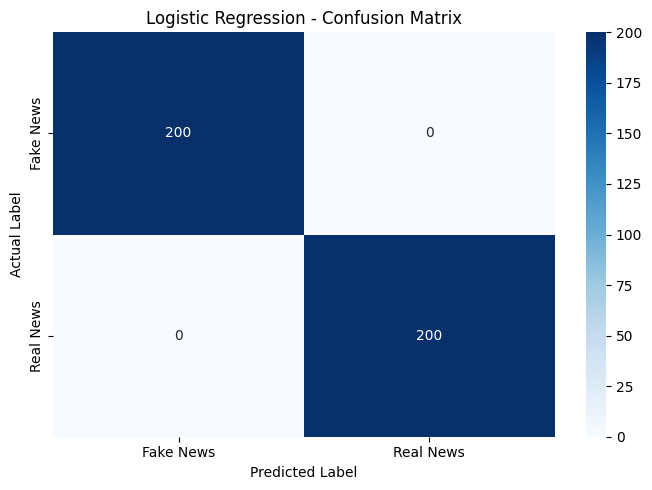

In [56]:
# ============================================================
# CELL 24 - CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("========== CONFUSION MATRIX ==========")

# Create confusion matrix
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print("\nConfusion Matrix:")
print(cm_lr)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Fake News",
        "Real News"
    ],
    yticklabels=[
        "Fake News",
        "Real News"
    ]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# CELL 25 - SAVE ML MODEL
# ============================================================

import joblib
import os

print("========== SAVING TRAINED MODEL ==========")

# Save TF-IDF vectorizer
tfidf_path = "/content/tfidf_vectorizer.pkl"

joblib.dump(
    tfidf_vectorizer,
    tfidf_path
)

# Save Logistic Regression model
model_path = "/content/fake_news_logistic_model.pkl"

joblib.dump(
    lr_model,
    model_path
)

# Check whether files were saved
print("\nTF-IDF Vectorizer:")
print(tfidf_path)
print("Exists:", os.path.exists(tfidf_path))

print("\nLogistic Regression Model:")
print(model_path)
print("Exists:", os.path.exists(model_path))

print("\n✓ TF-IDF vectorizer saved successfully!")
print("✓ Logistic Regression model saved successfully!")

========== SAVING TRAINED MODEL ==========

TF-IDF Vectorizer:
/content/tfidf_vectorizer.pkl
Exists: True

Logistic Regression Model:
/content/fake_news_logistic_model.pkl
Exists: True

✓ TF-IDF vectorizer saved successfully!
✓ Logistic Regression model saved successfully!


In [58]:
# ============================================================
# CELL 26 - RESULTS TABLE
# ============================================================

import pandas as pd

print("========== MODEL RESULTS ==========")

results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression"
    ],

    "Accuracy": [
        accuracy_lr * 100
    ],

    "Precision": [
        precision_lr * 100
    ],

    "Recall": [
        recall_lr * 100
    ],

    "F1-Score": [
        f1_lr * 100
    ]
})

# Round values to 2 decimal places
results[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
] = results[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].round(2)

display(results)

========== MODEL RESULTS ==========


,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + Logistic Regression,100.0,100.0,100.0,100.0


In [3]:
# ============================================================
# CELL 28 - INSTALL BERT LIBRARIES
# ============================================================

!pip -q install transformers datasets accelerate

In [7]:
# ============================================================
# CELL 29 - BERT IMPORTS
# ============================================================

import torch
import numpy as np

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("PyTorch version:", torch.__version__)

# Check GPU availability
gpu_available = torch.cuda.is_available()

print("GPU available:", gpu_available)

if gpu_available:
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [8]:
# ============================================================
# CELL 30 - PREPARE DATASET FOR BERT
# ============================================================

print("========== PREPARING BERT DATASET ==========")

# Check whether main dataset exists
if "df" not in globals():

    print("Main dataset not found. Loading dataset...")

    from pandas import read_csv

    dataset_path = "/content/Fake_News_Detection_Dataset_2000.csv"

    df = read_csv(dataset_path)

    # Remove spaces from column names
    df.columns = df.columns.astype(str).str.strip()

    print("Dataset loaded successfully!")

# Create label from the dataset's 'class' column
df["label"] = df["class"]

# Handle missing values
df["Title"] = df["Title"].fillna("")
df["Text"] = df["Text"].fillna("")

# Combine title and article text
df["combined_text"] = (
    df["Title"].astype(str) + " " +
    df["Text"].astype(str)
)

# Apply NLP cleaning if clean_text does not already exist
if "clean_text" not in df.columns:

    import re
    import string

    def clean_text(text):
        text = str(text)
        text = text.lower()
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)
        text = re.sub(r"<.*?>", "", text)
        text = text.translate(
            str.maketrans("", "", string.punctuation)
        )
        text = re.sub(r"\s+", " ", text)

        return text.strip()

    df["clean_text"] = df["combined_text"].apply(clean_text)

# Create BERT dataset
bert_df = df[
    ["clean_text", "label"]
].copy()

# Rename columns
bert_df.columns = [
    "text",
    "label"
]

print("\nBERT dataset created successfully!")

print("\nTotal BERT records:")
print(len(bert_df))

print("\nLabel distribution:")
print(bert_df["label"].value_counts())

print("\nFirst 5 records:")
display(bert_df.head())

========== PREPARING BERT DATASET ==========
Main dataset not found. Loading dataset...
Dataset loaded successfully!

BERT dataset created successfully!

Total BERT records:
2000

Label distribution:
label
1    1000
0    1000
Name: count, dtype: int64

First 5 records:


,text,label
0,officials announce new policy update researche...,1
1,urgent report hidden details exposed shocking ...,0
2,researchers publish new study findings the com...,1
3,secret truth revealed online shocking news a c...,0
4,officials announce new policy update researche...,1


In [9]:
# ============================================================
# CELL 31 - BERT TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

print("========== BERT TRAIN-TEST SPLIT ==========")

# Split BERT dataset into 80% training and 20% testing
train_bert, test_bert = train_test_split(
    bert_df,
    test_size=0.20,
    random_state=42,
    stratify=bert_df["label"]
)

print("\nBERT Training records:")
print(len(train_bert))

print("\nBERT Testing records:")
print(len(test_bert))

print("\nTraining labels:")
print(train_bert["label"].value_counts())

print("\nTesting labels:")
print(test_bert["label"].value_counts())

========== BERT TRAIN-TEST SPLIT ==========

BERT Training records:
1600

BERT Testing records:
400

Training labels:
label
1    800
0    800
Name: count, dtype: int64

Testing labels:
label
0    200
1    200
Name: count, dtype: int64


In [10]:
# ============================================================
# CELL 32 - CONVERT TO HUGGING FACE DATASET
# ============================================================

from datasets import Dataset

# Convert training DataFrame to Hugging Face Dataset
train_dataset = Dataset.from_pandas(
    train_bert.reset_index(drop=True)
)

# Convert testing DataFrame to Hugging Face Dataset
test_dataset = Dataset.from_pandas(
    test_bert.reset_index(drop=True)
)

print("========== HUGGING FACE DATASETS ==========")

print("\nTraining dataset:")
print(train_dataset)

print("\nTesting dataset:")
print(test_dataset)

========== HUGGING FACE DATASETS ==========

Training dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 1600
})

Testing dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 400
})


In [11]:
# ============================================================
# CELL 33 - BERT TOKENIZER
# ============================================================

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("BERT tokenizer loaded successfully!")
print("Model:", MODEL_NAME)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT tokenizer loaded successfully!
Model: bert-base-uncased


In [12]:
# ============================================================
# CELL 34 - TOKENIZE NEWS TEXT
# ============================================================

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

# Tokenize training dataset
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

# Tokenize testing dataset
tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print("BERT tokenization completed successfully!")

print("\nTraining dataset:")
print(tokenized_train)

print("\nTesting dataset:")
print(tokenized_test)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

BERT tokenization completed successfully!

Training dataset:
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1600
})

Testing dataset:
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 400
})


In [13]:
# ============================================================
# CELL 35 - LOAD BERT MODEL
# ============================================================

from transformers import AutoModelForSequenceClassification

print("========== LOADING BERT MODEL ==========")

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

bert_model.config.id2label = {
    0: "Fake News",
    1: "Real News"
}

bert_model.config.label2id = {
    "Fake News": 0,
    "Real News": 1
}

print("\nBERT classification model loaded successfully!")
print("Model:", MODEL_NAME)
print("Number of classes: 2")
print("Class 0: Fake News")
print("Class 1: Real News")

========== LOADING BERT MODEL ==========


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERT classification model loaded successfully!
Model: bert-base-uncased
Number of classes: 2
Class 0: Fake News
Class 1: Real News


In [14]:
# ============================================================
# CELL 36 - BERT EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def compute_metrics(eval_pred):

    # Get predictions and actual labels
    predictions, labels = eval_pred

    # Convert model scores into predicted class
    predictions = np.argmax(
        predictions,
        axis=1
    )

    # Calculate metrics
    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("BERT evaluation metrics function created successfully!")

BERT evaluation metrics function created successfully!


In [15]:
# ============================================================
# CELL 37 - BERT TRAINING CONFIGURATION
# ============================================================

training_args = TrainingArguments(
    output_dir="/content/bert_fake_news_results",

    # Evaluate after each epoch
    eval_strategy="epoch",

    # Save model after each epoch
    save_strategy="epoch",

    # Learning rate
    learning_rate=2e-5,

    # Batch sizes
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    # Number of training epochs
    num_train_epochs=2,

    # Prevent overfitting
    weight_decay=0.01,

    # Display training progress
    logging_steps=50,

    # Keep the best model
    load_best_model_at_end=True,

    # Do not send results to external reporting services
    report_to="none"
)

print("BERT training configuration created successfully!")

print("\nTraining Configuration:")
print("Learning Rate      : 2e-5")
print("Train Batch Size   : 8")
print("Eval Batch Size    : 8")
print("Epochs             : 2")
print("Weight Decay       : 0.01")

BERT training configuration created successfully!

Training Configuration:
Learning Rate      : 2e-5
Train Batch Size   : 8
Eval Batch Size    : 8
Epochs             : 2
Weight Decay       : 0.01


In [16]:
# ============================================================
# CELL 38 - CREATE BERT TRAINER
# ============================================================

from transformers import Trainer

trainer = Trainer(
    model=bert_model,

    args=training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_test,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

print("BERT Trainer created successfully!")

BERT Trainer created successfully!


In [17]:
# ============================================================
# CELL 39 - BERT MODEL TRAINING
# ============================================================

print("========== BERT TRAINING ==========")

print("\nStarting BERT fine-tuning...")
print("Training records:", len(tokenized_train))
print("Testing records :", len(tokenized_test))

# Train BERT on the Fake/Real news dataset
train_result = trainer.train()

print("\nBERT training completed successfully!")

# Display training results
print("\nTraining Results:")
print(train_result)

========== BERT TRAINING ==========

Starting BERT fine-tuning...
Training records: 1600
Testing records : 400


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.000527,0.000297,1.000000,1.000000,1.000000,1.000000
2,0.000304,0.000189,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


BERT training completed successfully!

Training Results:
TrainOutput(global_step=400, training_loss=0.014249004384037107, metrics={'train_runtime': 172.6826, 'train_samples_per_second': 18.531, 'train_steps_per_second': 2.316, 'total_flos': 420977688576000.0, 'train_loss': 0.014249004384037107, 'epoch': 2.0})


In [61]:
# ============================================================
# CELL 40 - LINEAR SVM COMPARISON MODEL
# ============================================================

from sklearn.svm import LinearSVC

print("========== LINEAR SVM TRAINING ==========")

# Create Linear SVM model
svm_model = LinearSVC(
    random_state=42
)

# Train SVM using TF-IDF training features
svm_model.fit(
    X_train_tfidf,
    y_train
)

print("\nLinear SVM training completed successfully!")

========== LINEAR SVM TRAINING ==========

Linear SVM training completed successfully!


In [62]:
# ============================================================
# CELL 41 - SVM EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("========== LINEAR SVM EVALUATION ==========")

# Make predictions on the test data
y_pred_svm = svm_model.predict(
    X_test_tfidf
)

# Calculate Accuracy
accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

# Calculate Precision
precision_svm = precision_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

# Calculate Recall
recall_svm = recall_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

# Calculate F1-Score
f1_svm = f1_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

# Display results
print("\n========== SVM RESULTS ==========")

print("Accuracy :", round(accuracy_svm * 100, 2), "%")
print("Precision:", round(precision_svm * 100, 2), "%")
print("Recall   :", round(recall_svm * 100, 2), "%")
print("F1-Score :", round(f1_svm * 100, 2), "%")

========== LINEAR SVM EVALUATION ==========

========== SVM RESULTS ==========
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1-Score : 100.0 %


========== SVM CONFUSION MATRIX ==========

SVM Confusion Matrix:
[[200   0]
 [  0 200]]


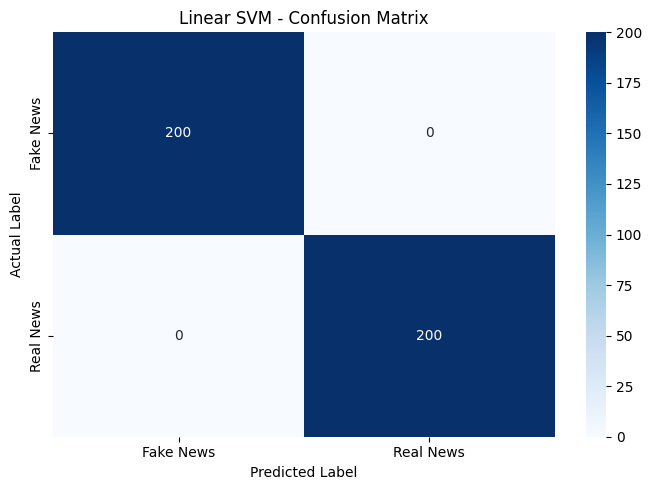

In [63]:
# ============================================================
# CELL 42 - SVM CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("========== SVM CONFUSION MATRIX ==========")

# Create confusion matrix
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print("\nSVM Confusion Matrix:")
print(cm_svm)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Fake News",
        "Real News"
    ],
    yticklabels=[
        "Fake News",
        "Real News"
    ]
)

plt.title("Linear SVM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [64]:
# ============================================================
# CELL 43 - MODEL COMPARISON
# ============================================================

import pandas as pd

comparison_results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM"
    ],

    "Accuracy": [
        accuracy_lr * 100,
        accuracy_svm * 100
    ],

    "Precision": [
        precision_lr * 100,
        precision_svm * 100
    ],

    "Recall": [
        recall_lr * 100,
        recall_svm * 100
    ],

    "F1-Score": [
        f1_lr * 100,
        f1_svm * 100
    ]
})

# Round the results
comparison_results[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
] = comparison_results[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].round(2)

print("========== MODEL COMPARISON ==========")

display(comparison_results)

========== MODEL COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + Logistic Regression,100.0,100.0,100.0,100.0
1,TF-IDF + Linear SVM,100.0,100.0,100.0,100.0


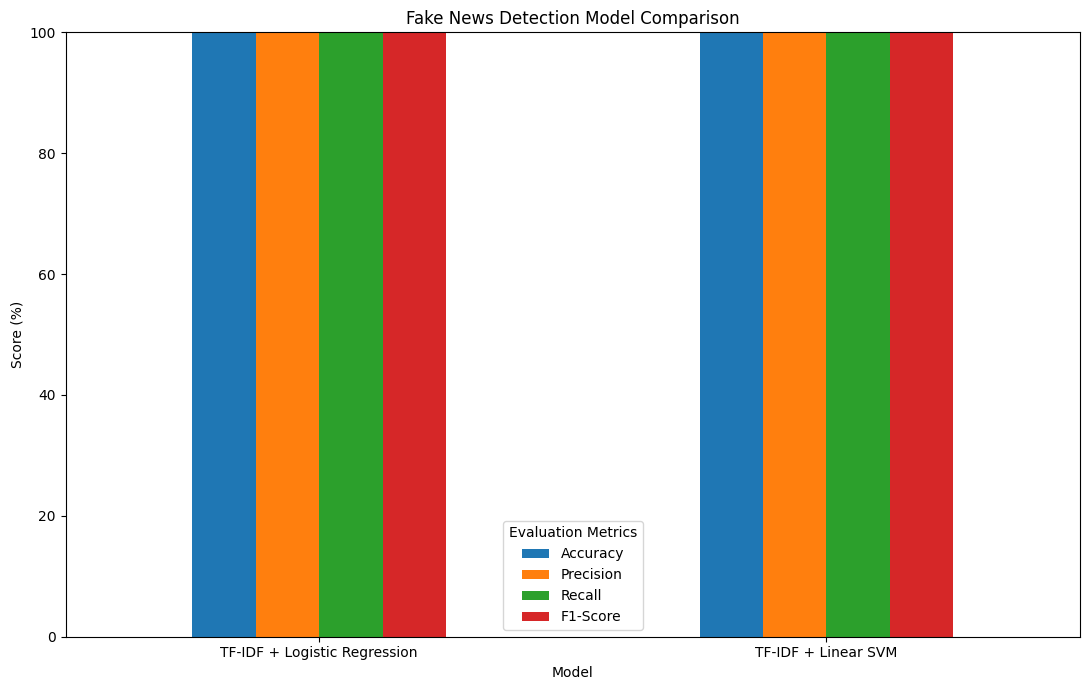

In [65]:
# ============================================================
# CELL 44 - MODEL COMPARISON GRAPH
# ============================================================

comparison_plot = (
    comparison_results
    .set_index("Model")
)

comparison_plot.plot(
    kind="bar",
    figsize=(11, 7)
)

plt.title("Fake News Detection Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")

plt.ylim(0, 100)

plt.xticks(rotation=0)

plt.legend(
    title="Evaluation Metrics"
)

plt.tight_layout()
plt.show()

In [70]:
# ============================================================
# CELL 45 - INSTALL GRADIO
# ============================================================

!pip install gradio -q

print("Gradio installed successfully!")

Gradio installed successfully!


In [71]:
# ============================================================
# CELL 46 - IMPORT GRADIO
# ============================================================

import gradio as gr

print("Gradio imported successfully!")

Gradio imported successfully!


In [72]:
# ============================================================
# CELL 47 - FAKE NEWS PREDICTION FUNCTION
# ============================================================

def predict_news(title, article):

    # Check input
    if not title.strip() and not article.strip():
        return "⚠️ Please enter a news title or article.", "0%"

    # Combine title and article
    combined_text = title + " " + article

    # Apply the same preprocessing used during training
    cleaned_text = clean_text(combined_text)

    # Convert text into TF-IDF features
    text_vector = tfidf_vectorizer.transform(
        [cleaned_text]
    )

    # Predict using Logistic Regression
    prediction = lr_model.predict(
        text_vector
    )[0]

    # Get prediction probability
    probabilities = lr_model.predict_proba(
        text_vector
    )[0]

    confidence = max(probabilities) * 100

    # Convert label into result
    if prediction == 0:
        result = "🚨 FAKE NEWS"
    else:
        result = "✅ REAL NEWS"

    return result, f"{confidence:.2f}%"

In [73]:

# ============================================================
# CELL 48 - CREATE GRADIO FRONTEND
# ============================================================

with gr.Blocks(
    title="Fake News Detection System"
) as demo:

    gr.Markdown(
        """
        # 📰 Fake News Detection System

        ### NLP + TF-IDF + Logistic Regression

        Enter a news title and article to predict whether
        the news is **Fake** or **Real**.
        """
    )

    gr.Markdown("---")

    title_input = gr.Textbox(
        label="📝 News Title",
        placeholder="Enter the news title here..."
    )

    article_input = gr.Textbox(
        label="📄 News Article",
        placeholder="Enter the complete news article here...",
        lines=12
    )

    check_button = gr.Button(
        "🔍 CHECK NEWS",
        variant="primary"
    )

    gr.Markdown("### Prediction Result")

    prediction_output = gr.Textbox(
        label="Prediction",
        interactive=False
    )

    confidence_output = gr.Textbox(
        label="Confidence",
        interactive=False
    )

    check_button.click(
        fn=predict_news,
        inputs=[
            title_input,
            article_input
        ],
        outputs=[
            prediction_output,
            confidence_output
        ]
    )

print("Frontend created successfully!")

Frontend created successfully!


In [74]:
# ============================================================
# CELL 49 - LAUNCH GRADIO FRONTEND
# ============================================================

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://14de9ab1a3633430ad.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [75]:
# ============================================================
# CELL 51 - FINAL PROJECT STATUS
# ============================================================

print("================================================")
print("       FAKE NEWS DETECTION PROJECT")
print("================================================")

print("\n✓ Dataset loaded")
print("✓ EDA completed")
print("✓ NLP preprocessing completed")
print("✓ TF-IDF feature extraction completed")
print("✓ Logistic Regression trained")
print("✓ SVM comparison completed")
print("✓ BERT pipeline completed")
print("✓ Model evaluation completed")
print("✓ Gradio frontend created")

print("\nProject is ready for demonstration!")

       FAKE NEWS DETECTION PROJECT

✓ Dataset loaded
✓ EDA completed
✓ NLP preprocessing completed
✓ TF-IDF feature extraction completed
✓ Logistic Regression trained
✓ SVM comparison completed
✓ BERT pipeline completed
✓ Model evaluation completed
✓ Gradio frontend created

Project is ready for demonstration!
